# Credit Risk Scoring - Exploratory Data Analysis

This notebook provides a comprehensive analysis of the Home Credit application dataset for credit risk scoring.


## 1. Load Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

## 2. Load Data

In [2]:
# Load the main application training dataset
data_path = '../data/raw/'
df = pd.read_csv(data_path + 'application_train.csv')

print(f"Main dataset loaded: {df.shape}")
print(f"First few rows:")
df.head()

Main dataset loaded: (307511, 122)
First few rows:


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


2. DATA OVERVIEW
Shape: (307511, 122)
Number of rows: 307,511
Number of columns: 122

Column names and types:
float64    65
int64      41
object     16
Name: count, dtype: int64

First few columns: ['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY']

--------------------------------------------------------------------------------
MISSING VALUES ANALYSIS
--------------------------------------------------------------------------------
                          Missing_Count  Percentage
COMMONAREA_AVG                   214865   69.872297
COMMONAREA_MODE                  214865   69.872297
COMMONAREA_MEDI                  214865   69.872297
NONLIVINGAPARTMENTS_MEDI         213514   69.432963
NONLIVINGAPARTMENTS_MODE         213514   69.432963
NONLIVINGAPARTMENTS_AVG          213514   69.432963
FONDKAPREMONT_MODE               210295   68.386172
LIVINGAPARTMENTS_AVG             2101

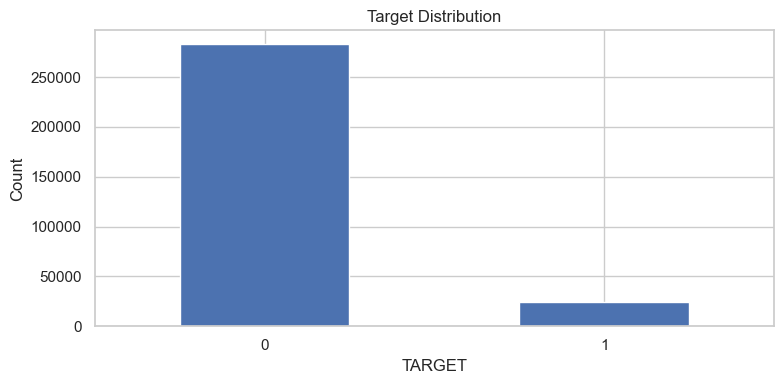

In [3]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Identify target column
target_candidates = [c for c in df.columns if c.lower() == "target" or c.lower().endswith("target")]
target_col = target_candidates[0] if target_candidates else None

print("=" * 80)
print("2. DATA OVERVIEW")
print("=" * 80)
print(f"Shape: {df.shape}")
print(f"Number of rows: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]}")
print(f"\nColumn names and types:")
print(df.dtypes.value_counts())
print(f"\nFirst few columns: {df.columns[:10].tolist()}")

print("\n" + "-" * 80)
print("MISSING VALUES ANALYSIS")
print("-" * 80)
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).sort_values(ascending=False)
missing_df = pd.DataFrame({
    'Missing_Count': missing[missing > 0],
    'Percentage': missing_pct[missing > 0]
})
print(missing_df.head(20))

print("\n" + "-" * 80)
print("TARGET IMBALANCE ANALYSIS")
print("-" * 80)
if target_col:
    print(f"Target column: {target_col}")
    target_dist = df[target_col].value_counts(normalize=True, dropna=False)
    print(target_dist)
    print(f"\nClass 0 (Good): {target_dist.get(0, 0):.2%}")
    print(f"Class 1 (Default): {target_dist.get(1, 0):.2%}")
    plt.figure(figsize=(8, 4))
    df[target_col].value_counts().plot(kind='bar')
    plt.title('Target Distribution')
    plt.xlabel(target_col)
    plt.ylabel('Count')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("No target column detected automatically. Expected column named `TARGET` or ending in `target`.")


3. NUMERICAL FEATURE ANALYSIS
Total numerical features: 105

--------------------------------------------------------------------------------
DISTRIBUTION STATISTICS
--------------------------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0,278180.518577,102790.175348,100002.0,189145.5,278202.0,367142.5,456255.0
CNT_CHILDREN,307511.0,0.417052,0.722121,0.0,0.0,0.0,1.0,19.0
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.0,112500.0,147150.0,202500.0,117000000.0
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.0,270000.0,513531.0,808650.0,4050000.0
AMT_ANNUITY,307499.0,27108.573909,14493.737315,1615.5,16524.0,24903.0,34596.0,258025.5
...,...,...,...,...,...,...,...,...
AMT_REQ_CREDIT_BUREAU_DAY,265992.0,0.007000,0.110757,0.0,0.0,0.0,0.0,9.0
AMT_REQ_CREDIT_BUREAU_WEEK,265992.0,0.034362,0.204685,0.0,0.0,0.0,0.0,8.0
AMT_REQ_CREDIT_BUREAU_MON,265992.0,0.267395,0.916002,0.0,0.0,0.0,0.0,27.0
AMT_REQ_CREDIT_BUREAU_QRT,265992.0,0.265474,0.794056,0.0,0.0,0.0,0.0,261.0



--------------------------------------------------------------------------------
OUTLIER DETECTION (IQR METHOD)
--------------------------------------------------------------------------------

Top 15 features with most outliers:
REGION_RATING_CLIENT           80527
REGION_RATING_CLIENT_W_CITY    78027
DAYS_EMPLOYED                  72217
REG_CITY_NOT_WORK_CITY         70867
FLAG_WORK_PHONE                61308
FLAG_EMP_PHONE                 55386
LIVE_CITY_NOT_WORK_CITY        55215
AMT_REQ_CREDIT_BUREAU_QRT      50575
AMT_REQ_CREDIT_BUREAU_MON      43759
DEF_30_CNT_SOCIAL_CIRCLE       35166
FLAG_DOCUMENT_6                27078
DEF_60_CNT_SOCIAL_CIRCLE       25769
FLAG_DOCUMENT_8                25024
REG_CITY_NOT_LIVE_CITY         24039
OBS_30_CNT_SOCIAL_CIRCLE       19971
dtype: int64


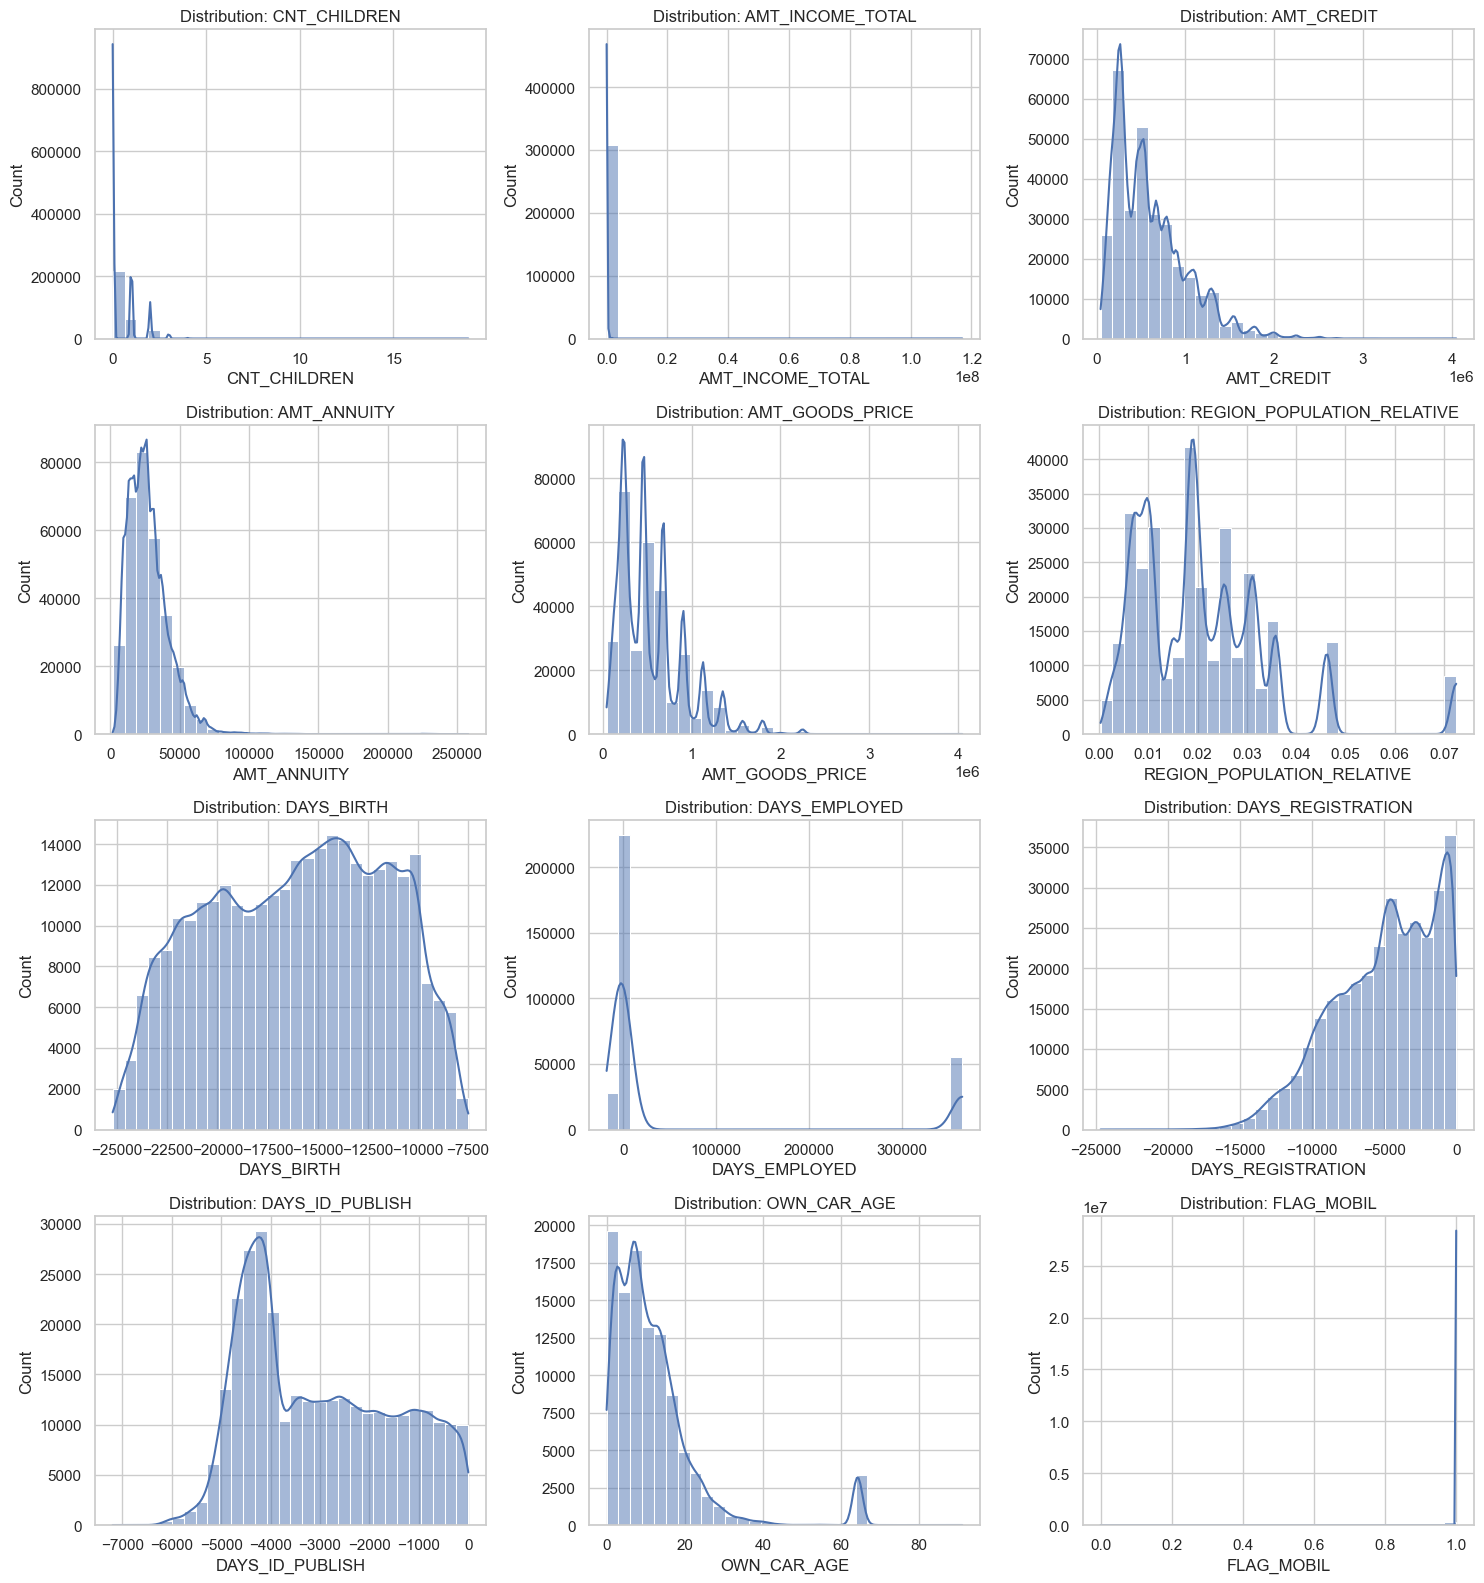

In [4]:
# Numerical feature analysis
num_cols = df.select_dtypes(include=np.number).columns.tolist()
if target_col and target_col in num_cols:
    num_cols.remove(target_col)

print("\n" + "=" * 80)
print("3. NUMERICAL FEATURE ANALYSIS")
print("=" * 80)
print(f"Total numerical features: {len(num_cols)}")

print("\n" + "-" * 80)
print("DISTRIBUTION STATISTICS")
print("-" * 80)
display(df[num_cols].describe().T)

print("\n" + "-" * 80)
print("OUTLIER DETECTION (IQR METHOD)")
print("-" * 80)
outlier_counts = {}
for col in num_cols:
    if df[col].dropna().empty:
        continue
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_counts[col] = ((df[col] < lower) | (df[col] > upper)).sum()

outlier_series = pd.Series(outlier_counts).sort_values(ascending=False)
print("\nTop 15 features with most outliers:")
print(outlier_series.head(15))

# Plot numeric distributions
numeric_plot_cols = [col for col in num_cols if col not in ['SK_ID_CURR', 'SK_ID_BUREAU', 'SK_ID_PREV']][:12]
if numeric_plot_cols:
    fig, axes = plt.subplots((len(numeric_plot_cols) + 2) // 3, 3, figsize=(15, 4 * ((len(numeric_plot_cols) + 2) // 3)))
    axes = axes.flatten()
    for ax, col in zip(axes, numeric_plot_cols):
        sns.histplot(df[col].dropna(), kde=True, ax=ax, bins=30)
        ax.set_title(f"Distribution: {col}")
    for ax in axes[len(numeric_plot_cols):]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()

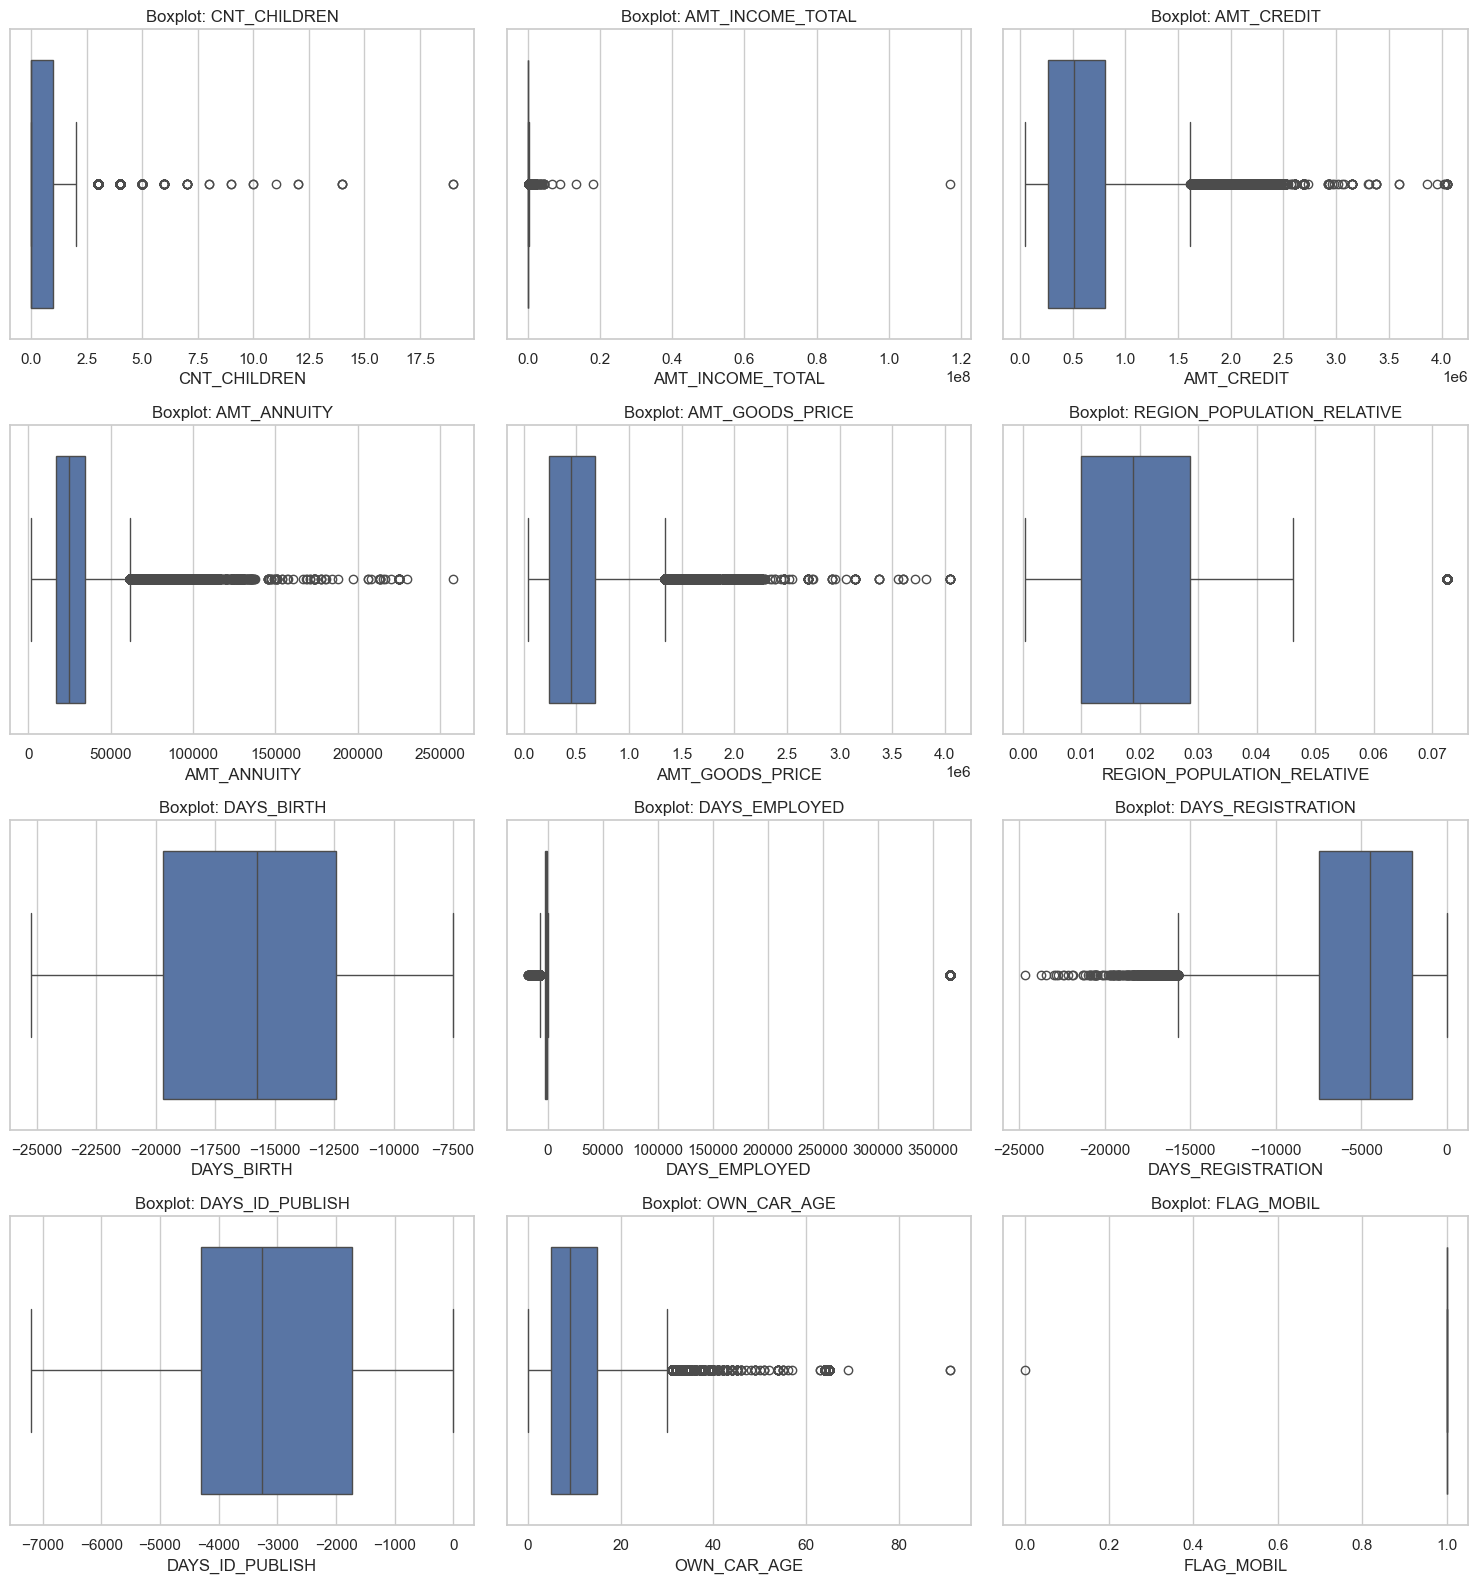

In [5]:
if numeric_plot_cols:
    fig, axes = plt.subplots((len(numeric_plot_cols) + 2) // 3, 3, figsize=(15, 4 * ((len(numeric_plot_cols) + 2) // 3)))
    axes = axes.flatten()
    for ax, col in zip(axes, numeric_plot_cols):
        sns.boxplot(x=df[col], ax=ax)
        ax.set_title(f"Boxplot: {col}")
    for ax in axes[len(numeric_plot_cols):]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()


4. CATEGORICAL FEATURE ANALYSIS
Total categorical features: 16
Categorical columns: ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE']...

--------------------------------------------------------------------------------
KEY CATEGORICAL FEATURES
--------------------------------------------------------------------------------

NAME_INCOME_TYPE
Unique values: 8
NAME_INCOME_TYPE
Working                 158774
Commercial associate     71617
Pensioner                55362
State servant            21703
Unemployed                  22
Student                     18
Businessman                 10
Maternity leave              5
Name: count, dtype: int64


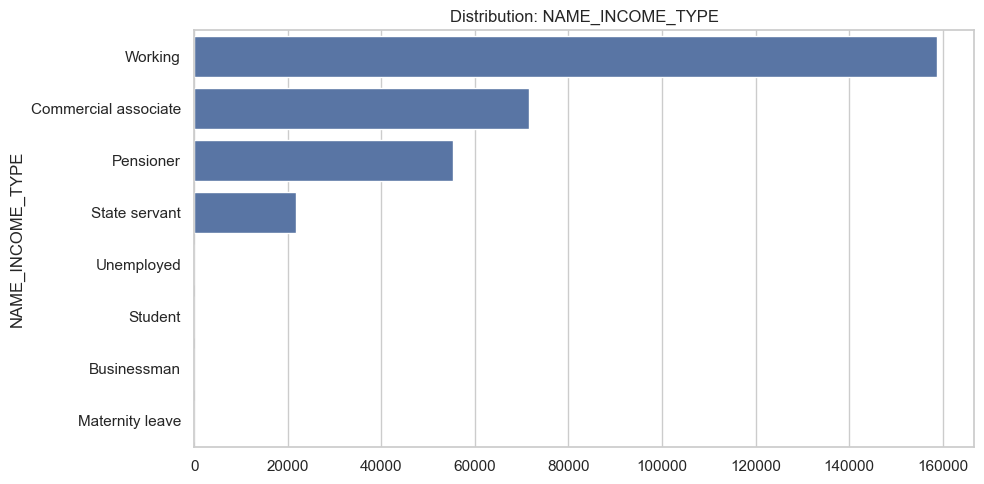


Default rate by NAME_INCOME_TYPE (%):


TARGET,0,1
NAME_INCOME_TYPE,,
Businessman,100.000000,0.000000
Commercial associate,92.515743,7.484257
Maternity leave,60.000000,40.000000
Pensioner,94.613634,5.386366
State servant,94.245035,5.754965
Student,100.000000,0.000000
Unemployed,63.636364,36.363636
Working,90.411528,9.588472



NAME_EDUCATION_TYPE
Unique values: 5
NAME_EDUCATION_TYPE
Secondary / secondary special    218391
Higher education                  74863
Incomplete higher                 10277
Lower secondary                    3816
Academic degree                     164
Name: count, dtype: int64


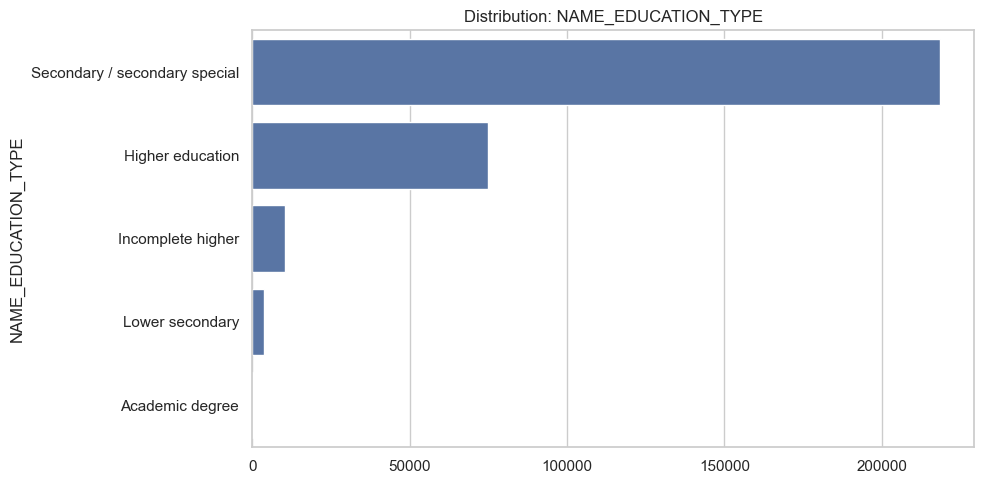


Default rate by NAME_EDUCATION_TYPE (%):


TARGET,0,1
NAME_EDUCATION_TYPE,,
Academic degree,98.170732,1.829268
Higher education,94.644885,5.355115
Incomplete higher,91.515034,8.484966
Lower secondary,89.072327,10.927673
Secondary / secondary special,91.060071,8.939929



NAME_FAMILY_STATUS
Unique values: 6
NAME_FAMILY_STATUS
Married                 196432
Single / not married     45444
Civil marriage           29775
Separated                19770
Widow                    16088
Unknown                      2
Name: count, dtype: int64


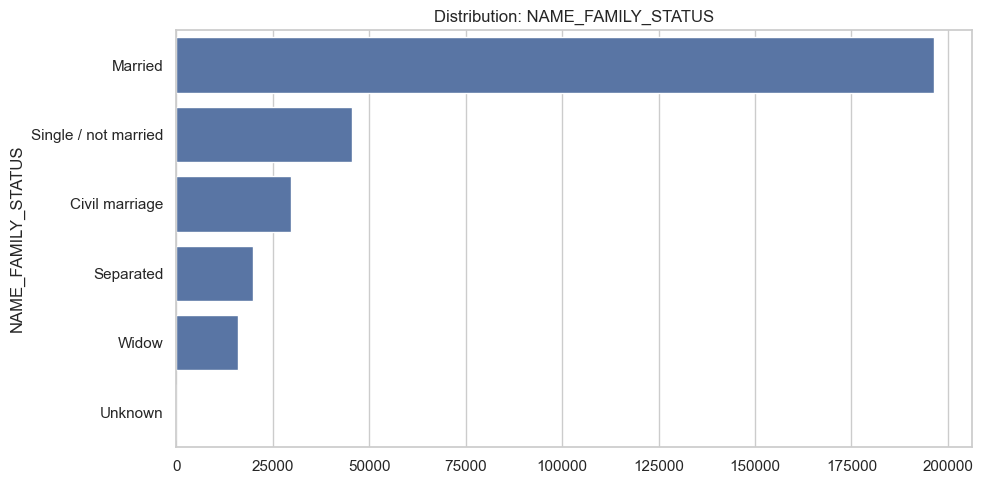


Default rate by NAME_FAMILY_STATUS (%):


TARGET,0,1
NAME_FAMILY_STATUS,,
Civil marriage,90.055416,9.944584
Married,92.440132,7.559868
Separated,91.805766,8.194234
Single / not married,90.192325,9.807675
Unknown,100.000000,0.000000
Widow,94.175783,5.824217



OCCUPATION_TYPE
Unique values: 18
OCCUPATION_TYPE
NaN                      96391
Laborers                 55186
Sales staff              32102
Core staff               27570
Managers                 21371
Drivers                  18603
High skill tech staff    11380
Accountants               9813
Medicine staff            8537
Security staff            6721
Name: count, dtype: int64


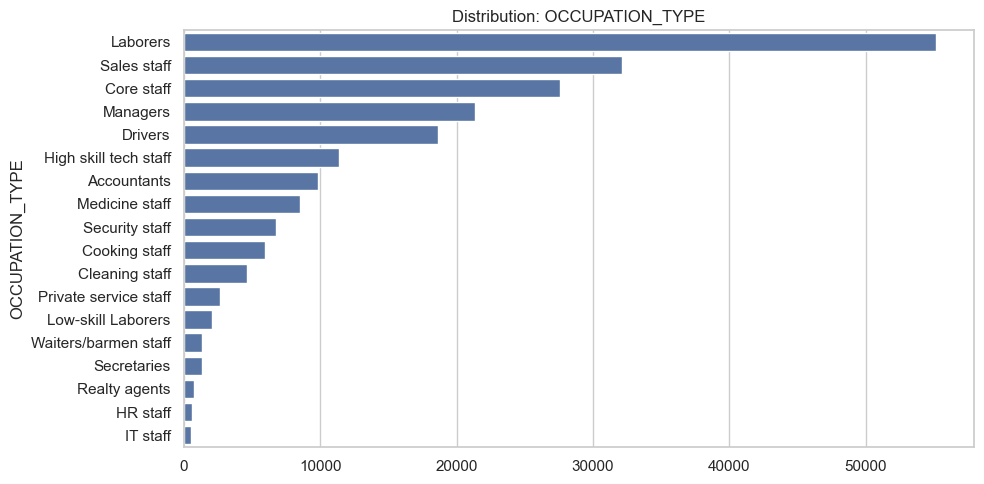


Default rate by OCCUPATION_TYPE (%):


TARGET,0,1
OCCUPATION_TYPE,,
Accountants,95.169673,4.830327
Cleaning staff,90.393295,9.606705
Cooking staff,89.556004,10.443996
Core staff,93.696046,6.303954
Drivers,88.673870,11.326130
HR staff,93.605684,6.394316
High skill tech staff,93.840070,6.159930
IT staff,93.536122,6.463878
Laborers,89.421230,10.578770



ORGANIZATION_TYPE
Unique values: 58
ORGANIZATION_TYPE
Business Entity Type 3    67992
XNA                       55374
Self-employed             38412
Other                     16683
Medicine                  11193
Business Entity Type 2    10553
Government                10404
School                     8893
Trade: type 7              7831
Kindergarten               6880
Name: count, dtype: int64


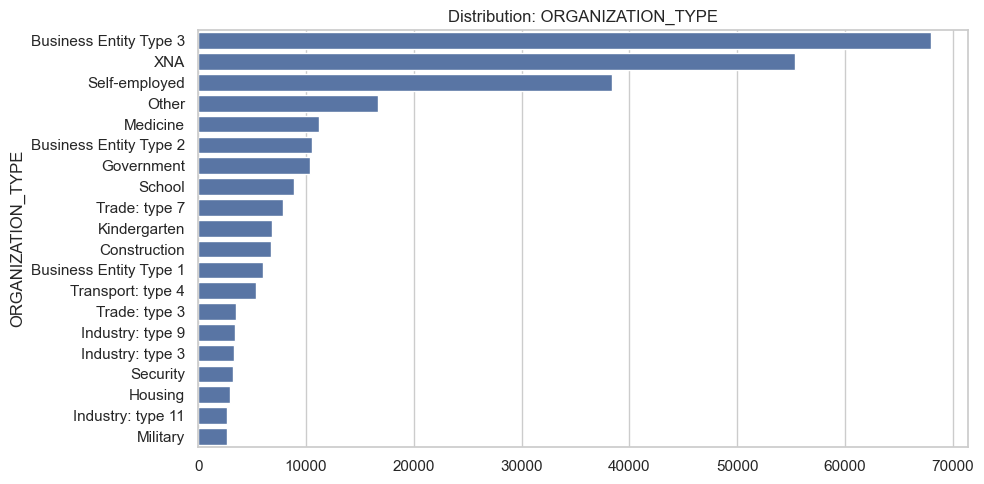


Default rate by ORGANIZATION_TYPE (%):


TARGET,0,1
ORGANIZATION_TYPE,,
Advertising,91.841492,8.158508
Agriculture,89.527302,10.472698
Bank,94.814519,5.185481
Business Entity Type 1,91.861631,8.138369
Business Entity Type 2,91.471619,8.528381
Business Entity Type 3,90.700377,9.299623
Cleaning,88.846154,11.153846
Construction,88.320190,11.679810
Culture,94.459103,5.540897


In [6]:

# Categorical feature analysis
categorical_cols = [c for c in df.columns if df[c].dtype == "object" or df[c].dtype.name == "category"]
requested_cat_cols = ["income_type", "education_type", "occupation_type", "family_status", "organization_type"]
requested_cat_cols_lower = [c.lower() for c in requested_cat_cols]
existing_requested = [df_col for df_col in df.columns 
                      if any(req.lower() in df_col.lower() for req in requested_cat_cols_lower) 
                      and df[df_col].dtype == "object"]

print("\n" + "=" * 80)
print("4. CATEGORICAL FEATURE ANALYSIS")
print("=" * 80)
print(f"Total categorical features: {len(categorical_cols)}")
print(f"Categorical columns: {categorical_cols[:10]}...")

print("\n" + "-" * 80)
print("KEY CATEGORICAL FEATURES")
print("-" * 80)

key_cat_features = existing_requested if existing_requested else categorical_cols[:5]
for col in key_cat_features[:5]:
    print(f"\n{col.upper()}")
    print(f"Unique values: {df[col].nunique()}")
    value_counts = df[col].value_counts(dropna=False)
    print(value_counts.head(10))
    
    # Plot
    plt.figure(figsize=(10, 5))
    plot_data = value_counts.head(20)
    sns.barplot(x=plot_data.values, y=plot_data.index)
    plt.title(f"Distribution: {col}")
    plt.tight_layout()
    plt.show()
    
    # Target relationship
    if target_col:
        ct = pd.crosstab(df[col], df[target_col], normalize="index") * 100
        print(f"\nDefault rate by {col} (%):")
        display(ct)



5. FEATURE ENGINEERING INSIGHTS

--------------------------------------------------------------------------------
CREDIT / INCOME RATIO
--------------------------------------------------------------------------------
Created CREDIT_INCOME_RATIO
count    307511.000000
mean          3.957537
std           2.689696
min           0.004808
25%           2.018659
50%           3.265042
75%           5.159857
max          84.733539
Name: CREDIT_INCOME_RATIO, dtype: float64

Credit/Income Ratio by target:
            mean    median       std
TARGET                              
0       3.963696  3.266622  2.695023
1       3.887405  3.253133  2.627312


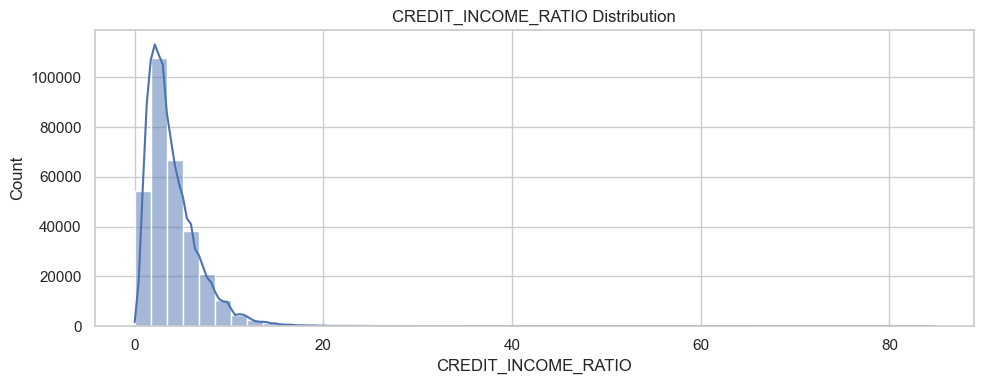


--------------------------------------------------------------------------------
ANNUITY / INCOME RATIO
--------------------------------------------------------------------------------
Created ANNUITY_INCOME_RATIO
count    307499.000000
mean          0.180928
std           0.094573
min           0.000224
25%           0.114781
50%           0.162832
75%           0.229064
max           1.875892
Name: ANNUITY_INCOME_RATIO, dtype: float64

Annuity/Income Ratio by target:
            mean    median       std
TARGET                              
0       0.180529  0.162279  0.094569
1       0.185481  0.169292  0.094495


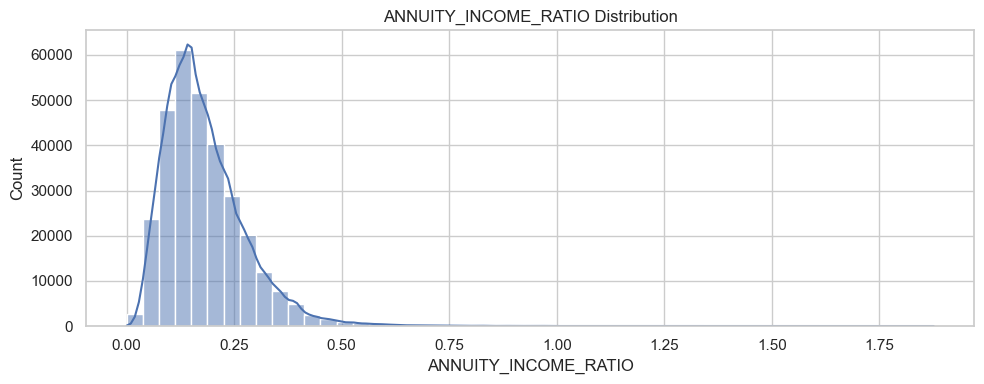

In [7]:
# Feature engineering insights
print("\n" + "=" * 80)
print("5. FEATURE ENGINEERING INSIGHTS")
print("=" * 80)

print("\n" + "-" * 80)
print("CREDIT / INCOME RATIO")
print("-" * 80)
if "AMT_CREDIT" in df.columns and "AMT_INCOME_TOTAL" in df.columns:
    df["CREDIT_INCOME_RATIO"] = df["AMT_CREDIT"] / (df["AMT_INCOME_TOTAL"] + 1)
    print("Created CREDIT_INCOME_RATIO")
    print(df["CREDIT_INCOME_RATIO"].describe())
    if target_col:
        print("\nCredit/Income Ratio by target:")
        print(df.groupby(target_col)["CREDIT_INCOME_RATIO"].agg(['mean', 'median', 'std']))
    plt.figure(figsize=(10, 4))
    sns.histplot(df["CREDIT_INCOME_RATIO"].replace([np.inf, -np.inf], np.nan).dropna(), kde=True, bins=50)
    plt.title("CREDIT_INCOME_RATIO Distribution")
    plt.tight_layout()
    plt.show()
else:
    print("Columns AMT_CREDIT and/or AMT_INCOME_TOTAL not available.")

print("\n" + "-" * 80)
print("ANNUITY / INCOME RATIO")
print("-" * 80)
if "AMT_ANNUITY" in df.columns and "AMT_INCOME_TOTAL" in df.columns:
    df["ANNUITY_INCOME_RATIO"] = df["AMT_ANNUITY"] / (df["AMT_INCOME_TOTAL"] + 1)
    print("Created ANNUITY_INCOME_RATIO")
    print(df["ANNUITY_INCOME_RATIO"].describe())
    if target_col:
        print("\nAnnuity/Income Ratio by target:")
        print(df.groupby(target_col)["ANNUITY_INCOME_RATIO"].agg(['mean', 'median', 'std']))
    plt.figure(figsize=(10, 4))
    sns.histplot(df["ANNUITY_INCOME_RATIO"].replace([np.inf, -np.inf], np.nan).dropna(), kde=True, bins=50)
    plt.title("ANNUITY_INCOME_RATIO Distribution")
    plt.tight_layout()
    plt.show()
else:
    print("Columns AMT_ANNUITY and/or AMT_INCOME_TOTAL not available.")


6. PREVIOUS APPLICATION ANALYSIS
Previous application data loaded: 1,670,214 rows, 37columns

Columns: ['SK_ID_PREV', 'SK_ID_CURR', 'NAME_CONTRACT_TYPE', 'AMT_ANNUITY', 'AMT_APPLICATION', 'AMT_CREDIT', 'AMT_DOWN_PAYMENT', 'AMT_GOODS_PRICE', 'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START', 'FLAG_LAST_APPL_PER_CONTRACT', 'NFLAG_LAST_APPL_IN_DAY', 'RATE_DOWN_PAYMENT', 'RATE_INTEREST_PRIMARY', 'RATE_INTEREST_PRIVILEGED', 'NAME_CASH_LOAN_PURPOSE', 'NAME_CONTRACT_STATUS', 'DAYS_DECISION', 'NAME_PAYMENT_TYPE', 'CODE_REJECT_REASON', 'NAME_TYPE_SUITE', 'NAME_CLIENT_TYPE', 'NAME_GOODS_CATEGORY', 'NAME_PORTFOLIO', 'NAME_PRODUCT_TYPE', 'CHANNEL_TYPE', 'SELLERPLACE_AREA', 'NAME_SELLER_INDUSTRY', 'CNT_PAYMENT', 'NAME_YIELD_GROUP', 'PRODUCT_COMBINATION', 'DAYS_FIRST_DRAWING', 'DAYS_FIRST_DUE', 'DAYS_LAST_DUE_1ST_VERSION', 'DAYS_LAST_DUE', 'DAYS_TERMINATION', 'NFLAG_INSURED_ON_APPROVAL']

--------------------------------------------------------------------------------
CONTRACT APPROVAL STATUS

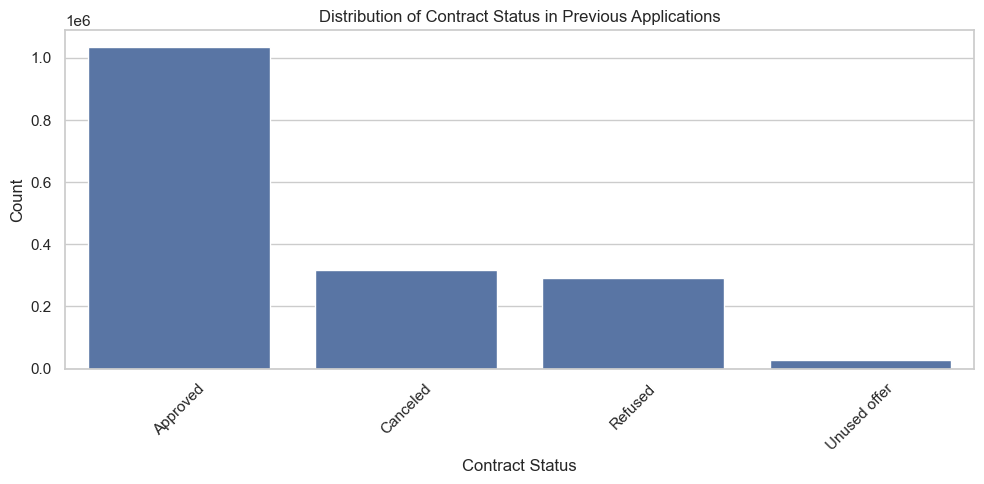


--------------------------------------------------------------------------------
CONTRACT PRODUCT TYPE & LOAN PURPOSE
--------------------------------------------------------------------------------
Product Type Distribution:
NAME_CONTRACT_TYPE
Cash loans         747553
Consumer loans     729151
Revolving loans    193164
XNA                   346
Name: count, dtype: int64


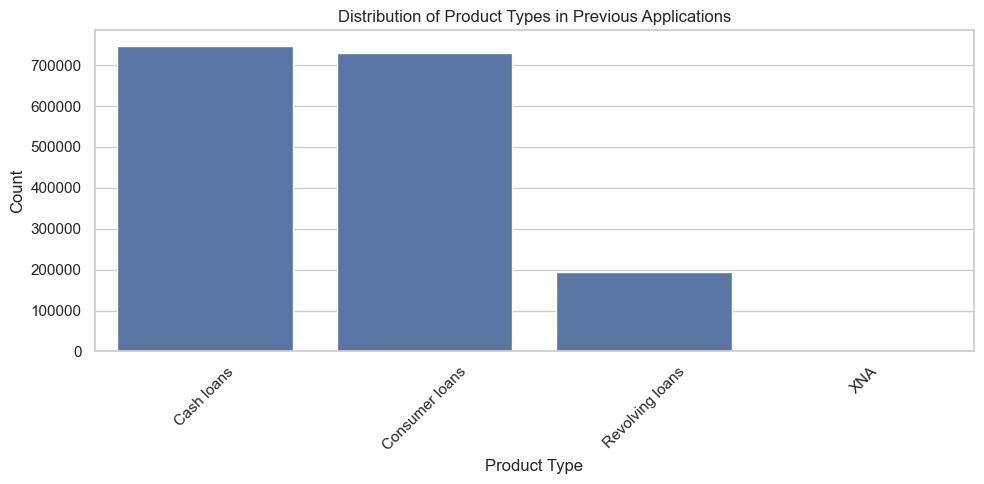



Cash Loan Purpose Distribution:
NAME_CASH_LOAN_PURPOSE
XAP                                 922661
XNA                                 677918
Repairs                              23765
Other                                15608
Urgent needs                          8412
Buying a used car                     2888
Building a house or an annex          2693
Everyday expenses                     2416
Medicine                              2174
Payments on other loans               1931
Education                             1573
Journey                               1239
Purchase of electronic equipment      1061
Buying a new car                      1012
Wedding / gift / holiday               962
Name: count, dtype: int64


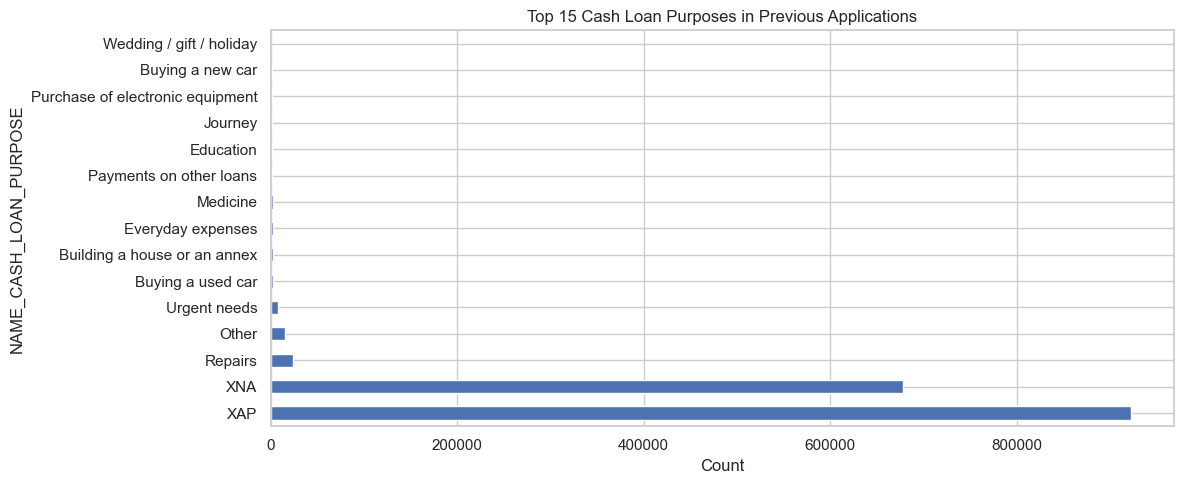


--------------------------------------------------------------------------------
TYPE OF LOAN (CASH/POS/CAR/REVOLVING)
--------------------------------------------------------------------------------
Loan Type Distribution:
  Cash loans: 747553 (44.76%)
  Consumer loans: 729151 (43.66%)
  Revolving loans: 193164 (11.57%)
  XNA: 346 (0.02%)

--------------------------------------------------------------------------------
CLIENT TENURE - OLD vs NEW CLIENT
--------------------------------------------------------------------------------
New Clients (1st application): 60458 (17.84%)
Returning Clients (2+ applications): 278399 (82.16%)

Repeating Client Statistics:
  Max applications by one client: 77
  Avg applications per returning client: 5.78

--------------------------------------------------------------------------------
TOP ACQUISITION CHANNELS
--------------------------------------------------------------------------------
Acquisition Channels:
CHANNEL_TYPE
Credit and cash offices  

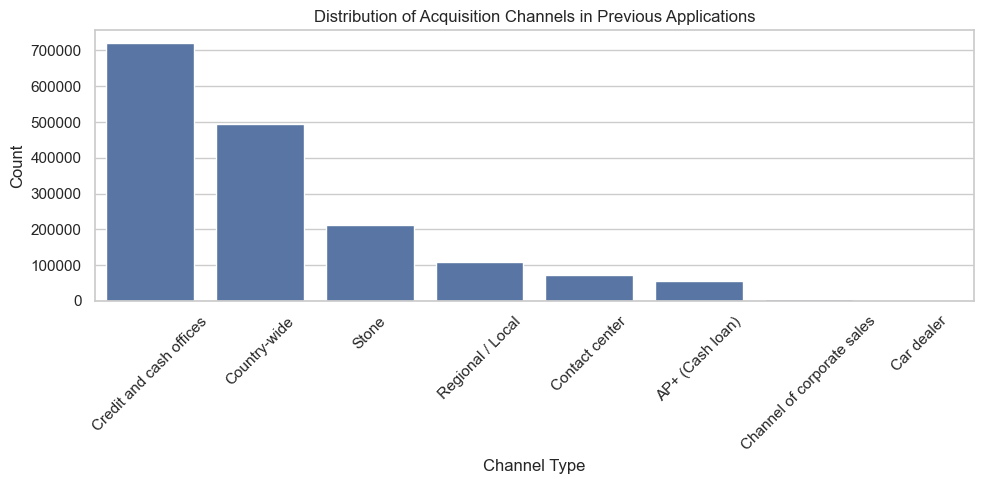


--------------------------------------------------------------------------------
CLIENT PAYMENT METHOD PREFERENCE
--------------------------------------------------------------------------------
Payment Method Distribution:
NAME_PAYMENT_TYPE
Cash through the bank                        1033552
XNA                                           627384
Non-cash from your account                      8193
Cashless from the account of the employer       1085
Name: count, dtype: int64


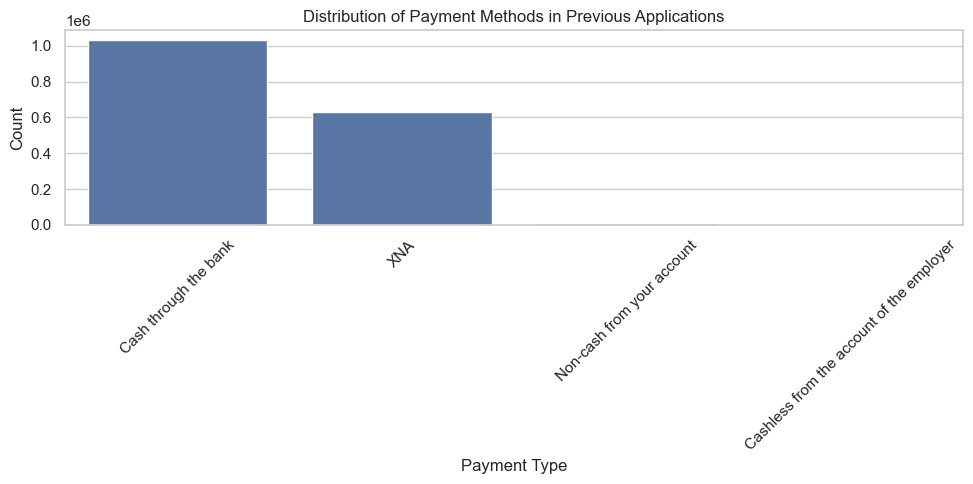


--------------------------------------------------------------------------------
RELATIONSHIP WITH CURRENT DEFAULT RISK
--------------------------------------------------------------------------------

>>> DEFAULT RATE COMPARISON <<<

Customers WITHOUT previous rejection history: 6.98% default rate
Customers WITH previous rejection history: 10.32% default rate
  → Risk increase: 3.34 percentage points

Default rate by number of previous applications:
                default_pct  count
PREV_APP_COUNT                    
0.0                    5.96  16454
1.0                    8.38  52533
2.0                    7.86  45799
3.0                    7.81  40014
4.0                    7.56  32922
5.0                    7.88  26638
6.0                    7.95  21073
7.0                    8.23  16384
8.0                    8.31  12785
9.0                    8.56   9767

Default rate by previous approval rate:
                      default_pct   count
APPROVAL_RATE_BUCKET                     

In [17]:
print("\n" + "=" * 80)
print("6. PREVIOUS APPLICATION ANALYSIS")
print("=" * 80)

try:
    data_path = '../data/raw/'
    prev = pd.read_csv(data_path + 'previous_application.csv')
    print(f"Previous application data loaded: {prev.shape[0]:,} rows, {prev.shape[1]}columns")
    print(f"\nColumns: {prev.columns.tolist()}\n")
    print("-" * 80)
    print("CONTRACT APPROVAL STATUS")
    print("-" * 80)
    contract_status_dist = prev['NAME_CONTRACT_STATUS'].value_counts()
    print(f"Contract Status Distribution:")
    print(contract_status_dist)
    print(f"\nApproval Rate: {(contract_status_dist.get('Approved', 0) / len(prev) * 100):.2f}%")
    print(f"Refusal Rate: {(contract_status_dist.get('Refused', 0) / len(prev) * 100):.2f}%")
    
    # Visualize contract status
    plt.figure(figsize=(10, 5))
    sns.countplot(x='NAME_CONTRACT_STATUS', data=prev, order=contract_status_dist.index)
    plt.title('Distribution of Contract Status in Previous Applications')
    plt.xlabel('Contract Status')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    print("\n" + "-" * 80)
    print("CONTRACT PRODUCT TYPE & LOAN PURPOSE")
    print("-" * 80)
    
    if 'NAME_CONTRACT_TYPE' in prev.columns:
        product_type = prev['NAME_CONTRACT_TYPE'].value_counts()
        print(f"Product Type Distribution:")
        print(product_type)
        
        plt.figure(figsize=(10, 5))
        sns.countplot(x='NAME_CONTRACT_TYPE', data=prev, order=product_type.index)
        plt.title('Distribution of Product Types in Previous Applications')
        plt.xlabel('Product Type')
        plt.ylabel('Count')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    
    if 'NAME_CASH_LOAN_PURPOSE' in prev.columns:
        print(f"\n\nCash Loan Purpose Distribution:")
        loan_purpose = prev['NAME_CASH_LOAN_PURPOSE'].value_counts().head(15)
        print(loan_purpose)
        
        plt.figure(figsize=(12, 5))
        loan_purpose.plot(kind='barh')
        plt.title('Top 15 Cash Loan Purposes in Previous Applications')
        plt.xlabel('Count')
        plt.tight_layout()
        plt.show()
    
    print("\n" + "-" * 80)
    print("TYPE OF LOAN (CASH/POS/CAR/REVOLVING)")
    print("-" * 80)
    # Assuming NAME_CONTRACT_TYPE gives loan type or create from available column
    if 'NAME_CONTRACT_TYPE' in prev.columns:
        loan_type = prev['NAME_CONTRACT_TYPE'].value_counts()
        print(f"Loan Type Distribution:")
        for loan, count in loan_type.items():
            print(f"  {loan}: {count} ({count/len(prev)*100:.2f}%)")
    
    print("\n" + "-" * 80)
    print("CLIENT TENURE - OLD vs NEW CLIENT")
    print("-" * 80)
    
    # Identify new vs returning clients
    prev_counts = prev.groupby('SK_ID_CURR').size()
    new_clients = (prev_counts == 1).sum()
    returning_clients = (prev_counts > 1).sum()
    repeat_clients = prev_counts[prev_counts > 1]
    
    print(f"New Clients (1st application): {new_clients} ({new_clients/(new_clients+returning_clients)*100:.2f}%)")
    print(f"Returning Clients (2+ applications): {returning_clients} ({returning_clients/(new_clients+returning_clients)*100:.2f}%)")
    print(f"\nRepeating Client Statistics:")
    print(f"  Max applications by one client: {repeat_clients.max()}")
    print(f"  Avg applications per returning client: {repeat_clients.mean():.2f}")
    
    print("\n" + "-" * 80)
    print("TOP ACQUISITION CHANNELS")
    print("-" * 80)
    
    if 'CHANNEL_TYPE' in prev.columns:
        channels = prev['CHANNEL_TYPE'].value_counts()
        print(f"Acquisition Channels:")
        print(channels)
        
        plt.figure(figsize=(10, 5))
        sns.countplot(x='CHANNEL_TYPE', data=prev, order=channels.index)
        plt.title('Distribution of Acquisition Channels in Previous Applications')
        plt.xlabel('Channel Type')
        plt.ylabel('Count')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    
    print("\n" + "-" * 80)
    print("CLIENT PAYMENT METHOD PREFERENCE")
    print("-" * 80)
    
    if 'NAME_PAYMENT_TYPE' in prev.columns:
        payment_methods = prev['NAME_PAYMENT_TYPE'].value_counts()
        print(f"Payment Method Distribution:")
        print(payment_methods)
        
        plt.figure(figsize=(10, 5))
        sns.countplot(x='NAME_PAYMENT_TYPE', data=prev, order=payment_methods.index)
        plt.title('Distribution of Payment Methods in Previous Applications')
        plt.xlabel('Payment Type')
        plt.ylabel('Count')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    
    # ============================================================================
    # AGGREGATE FEATURES FOR CURRENT CUSTOMERS & RELATIONSHIP WITH DEFAULT
    # ============================================================================
    print("\n" + "-" * 80)
    print("RELATIONSHIP WITH CURRENT DEFAULT RISK")
    print("-" * 80)
    
    # 1. Count of previous applications per customer
    prev_agg = prev.groupby('SK_ID_CURR').size().reset_index(name='PREV_APP_COUNT')
    
    # 2. Count of refused applications per customer
    refused_df = prev[prev['NAME_CONTRACT_STATUS'] == 'Refused']
    refused_agg = refused_df.groupby('SK_ID_CURR').size().reset_index(name='PREV_REFUSED_COUNT')
    
    # 3. Count of approved applications per customer
    approved_df = prev[prev['NAME_CONTRACT_STATUS'] == 'Approved']
    approved_agg = approved_df.groupby('SK_ID_CURR').size().reset_index(name='PREV_APPROVED_COUNT')
    
    # Merge all features
    prev_features = prev_agg.copy()
    prev_features = pd.merge(prev_features, refused_agg, on='SK_ID_CURR', how='left')
    prev_features = pd.merge(prev_features, approved_agg, on='SK_ID_CURR', how='left')
    prev_features['PREV_REFUSED_COUNT'] = prev_features['PREV_REFUSED_COUNT'].fillna(0)
    prev_features['PREV_APPROVED_COUNT'] = prev_features['PREV_APPROVED_COUNT'].fillna(0)
    prev_features['APPROVAL_RATE'] = prev_features['PREV_APPROVED_COUNT'] / prev_features['PREV_APP_COUNT']
    
    # Merge with main dataset
    if 'SK_ID_CURR' in df.columns and target_col in df.columns:
        df_merged = df.merge(prev_features, on='SK_ID_CURR', how='left')
        df_merged['PREV_APP_COUNT'] = df_merged['PREV_APP_COUNT'].fillna(0)
        df_merged['PREV_REFUSED_COUNT'] = df_merged['PREV_REFUSED_COUNT'].fillna(0)
        df_merged['PREV_APPROVED_COUNT'] = df_merged['PREV_APPROVED_COUNT'].fillna(0)
        df_merged['APPROVAL_RATE'] = df_merged['APPROVAL_RATE'].fillna(0)
        
        # Key insights
        print("\n>>> DEFAULT RATE COMPARISON <<<\n")
        
        # By previous refusal history
        has_refused = (df_merged['PREV_REFUSED_COUNT'] > 0).astype(int)
        default_by_refusal = df_merged.groupby(has_refused)[target_col].mean() * 100
        print(f"Customers WITHOUT previous rejection history: {default_by_refusal.loc[0]:.2f}% default rate")
        if 1 in default_by_refusal.index:
            print(f"Customers WITH previous rejection history: {default_by_refusal.loc[1]:.2f}% default rate")
            print(f"  → Risk increase: {default_by_refusal.loc[1] - default_by_refusal.loc[0]:.2f} percentage points\n")
        
        # By number of previous applications
        print(f"Default rate by number of previous applications:")
        app_count_default = df_merged.groupby('PREV_APP_COUNT')[target_col].agg(['mean', 'count']).round(4)
        app_count_default['default_pct'] = app_count_default['mean'] * 100
        print(app_count_default[['default_pct', 'count']].head(10))
        
        # By approval rate
        print(f"\nDefault rate by previous approval rate:")
        df_merged['APPROVAL_RATE_BUCKET'] = pd.cut(df_merged['APPROVAL_RATE'], bins=[-.1, 0, 0.5, 1], 
                                                     labels=['No History', 'Low (0-50%)', 'High (50-100%)'])
        approval_default = df_merged.groupby('APPROVAL_RATE_BUCKET')[target_col].agg(['mean', 'count'])
        approval_default['default_pct'] = approval_default['mean'] * 100
        print(approval_default[['default_pct', 'count']])
    
except FileNotFoundError:
    print("Error: 'previous_application.csv' file not found in the specified path.")

# =========================================================================================

print("\n" + "=" * 80)
print("7. KEY BUSINESS INSIGHTS")
print("=" * 80)
insights = []

if target_col in df.columns:
    base_rate = df[target_col].mean()
    insights.append(f"Tỷ lệ nợ xấu tổng thể: {base_rate:.2%}")

if "AMT_INCOME_TOTAL" in df.columns:
    med_income = df["AMT_INCOME_TOTAL"].median()
    insights.append(f"Thu nhập trung vị (Median Income): ${med_income:,.0f}")

if "AMT_CREDIT" in df.columns:
    med_credit = df["AMT_CREDIT"].median()
    insights.append(f"Khoản vay trung vị: ${med_credit:,.0f}")

if "DAYS_BIRTH" in df.columns:
    age = -df["DAYS_BIRTH"] / 365.25
    insights.append(f"Độ tuổi trung bình của khách hàng: {age.mean():.1f} tuổi")

for line in insights:
    print(f"• {line}")

In [ ]:
# Feature importance
print("\n" + "=" * 80)
print("8. FEATURE IMPORTANCE")
print("=" * 80)

if target_col is None:
    print("Target column not found, cannot compute feature importance.")
else:
    print("\n" + "-" * 80)
    print("CORRELATION WITH TARGET")
    print("-" * 80)
    available_num_cols = [c for c in num_cols if c in df.columns]
    if target_col in df.columns and available_num_cols:
        corr = df[available_num_cols + [target_col]].corr()[target_col].sort_values(ascending=False)
        corr_plot = corr.drop(target_col, errors='ignore')
        print("\nTop 15 correlated features:")
        print(corr_plot.head(15))
        
        plt.figure(figsize=(10, 8))
        sns.barplot(x=corr_plot.head(15).values, y=corr_plot.head(15).index)
        plt.title("Top 15 Features Correlated with Target")
        plt.tight_layout()
        plt.show()

    print("\n" + "-" * 80)
    print("RANDOM FOREST FEATURE IMPORTANCE")
    print("-" * 80)
    
    model_cols = [c for c in num_cols if c in df.columns and c not in ['SK_ID_CURR', 'SK_ID_BUREAU', 'SK_ID_PREV']]
    cat_cols_for_model = [c for c in categorical_cols if df[c].nunique() < 50]
    
    if not model_cols:
        print("No features available for Random Forest.")
    else:
        X = df[model_cols + cat_cols_for_model].copy()
        y = df[target_col].copy()
        
        # Handle categorical variables
        X = pd.get_dummies(X, drop_first=True)
        
        # Impute missing values
        imputer = SimpleImputer(strategy="median")
        X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)
        
        # Remove rows with missing target
        valid_idx = y.notna()
        X_imputed = X_imputed[valid_idx]
        y = y[valid_idx]
        
        if len(X_imputed) > 0 and y.nunique() > 1:
            X_train, X_test, y_train, y_test = train_test_split(
                X_imputed, y, test_size=0.2, random_state=42, stratify=y
            )
            
            rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1, verbose=0)
            rf.fit(X_train, y_train)
            
            train_score = rf.score(X_train, y_train)
            test_score = rf.score(X_test, y_test)
            print(f"\nRandom Forest Model Performance:")
            print(f"Train Accuracy: {train_score:.4f}")
            print(f"Test Accuracy: {test_score:.4f}")
            
            importances = pd.Series(rf.feature_importances_, index=X_imputed.columns).sort_values(ascending=False)
            print("\nTop 20 Random Forest Feature Importances:")
            print(importances.head(20))
            
            plt.figure(figsize=(10, 12))
            sns.barplot(x=importances.head(20).values, y=importances.head(20).index)
            plt.title("Top 20 Random Forest Feature Importances")
            plt.xlabel("Importance")
            plt.tight_layout()
            plt.show()
        else:
            print("Insufficient data or target variance for Random Forest modeling.")


8. FEATURE IMPORTANCE

--------------------------------------------------------------------------------
CORRELATION WITH TARGET
--------------------------------------------------------------------------------
